# Share-Class Spreads — a quantitative teardown 🔬
### Bound violations by threshold + tail asymmetry · HAC t on the structural discount, by era · the bounded/unbounded half-life contrast · fill-at-print vs next-close collapse on two trading rules · a planted-bound synthetic control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Tradable for A-holders?: Busted](https://img.shields.io/badge/Tradable_for_A--holders%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim is contractual, not statistical — Berkshire's charter gives every A-holder a 1→1,500 conversion option, B-to-A does not exist, and Alphabet's twins have no bridge at all — so the job is to *measure the enforcement* and then to test, honestly, whether anything is left to trade.

> ⚠️ **Data note.** yfinance daily split-adjusted closes; BRK pair 1996-05-09 → 2026-06-30 (7,583 days, adjusted parity a constant 1,500), GOOG pair 2014-04-03 → 2026-06-30 (3,078 days). Price-only returns (neither BRK class ever paid a dividend; Google's 2024+ dividends are identical across classes and cancel in the ratio). No panel, no survivorship screen — two named pairs, nothing searched over. BRK-A's close is stale/wide (a few hundred trades/day at ~$750k), so sub-10-bps 'premiums' are print noise; the bound is judged at 50–100 bps. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `145603f5d518`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from share_class_spreads import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    PX = PX[PX.index <= "2026-06-30"]              # frozen as-of (docs/results.md)
    BRK = st.gap_series(PX, "BRK-A", "BRK-B", data.BRK_PARITY, start=data.BRKB_START)
    GOO = st.gap_series(PX, "GOOG", "GOOGL", 1.0, start=data.GOOG_START)
else:
    PX = BRK = GOO = None
print("real tape cached:", HAVE_REAL,
      "| BRK pair days:", (0 if BRK is None else len(BRK)),
      "| GOOG pair days:", (0 if GOO is None else len(GOO)))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fingerprint': '145603f5d518', 'brk_days': 7583, 'brk_start': '1996-05-09', 'goog_days': 3078, 'goog_start': '2014-04-03', 'viol': [(0, 35.8, 2715), (10, 18.08, 1371), (50, 1.77, 134), (100, 0.24, 18)], 'worst_up_bps': 194, 'worst_up_date': '2020-03-13', 'worst_dn_bps': -700, 'worst_dn_date': '2009-02-20', 'asym_brk': 13.0, 'brk_dn50': 22.95, 'brk_up50': 1.77, 'asym_goog': 0.7, 'goog_up50': 40.16, 'goog_dn50': 26.74, 'mean_bps': -35.5, 'hac_t': -12.53, 'hac_lags': 10, 'median_bps': -8.2, 'std_bps': 82, 'p1_bps': -385.7, 'p99_bps': 62.7, 'brk_eras': [('1996-2009', -55.1, -10.82, 33.9), ('2010-2019', -7.1, -5.99, 44.9), ('2020-2026', -37.7, -10.83, 25.9)], 'goog_mean_bps': 51.6, 'goog_t': 6.45, 'goog_std': 149, 'goog_min': -435, 'goog_max': 531, 'goog_eras': [('2014-2017', 237.5, 28.59, 0), ('2018-2021', -4.8, -0.65, 50), ('2022-2026', -53.9, -14.74, 90)], 'rho_brk': 0.8566, 'hl_brk': 4.5, 'rho_goog': 0.9919, 'hl_goog': 85.2, 'pairs_diag': (8.42, 9.38, 33), 'pairs': [(2.0, 0.21, 0.38), (5.0, -0.95, -1.69), (10.0, -2.87, -4.75)], 'sw_diag': (4.27, 6.02, 158, 23), 'switch': [(0.5, -0.56, -1.03, -1.06, -0.93, -0.15, -0.39), (1.0, 0.14, 0.28, 0.13, 0.12, 0.14, 0.43), (2.0, 0.3, 0.73, 0.67, 0.74, -0.01, -0.04), (3.0, 0.42, 1.18, 0.76, 0.95, 0.14, 1.0)], 'syn': [('PLANTED bound -40 bps', -54.9, -33.86, 0.0, 52.64), ('NULL no bound, 0', -3.1, -1.5, 14.4, 16.98)]}


real tape cached: True | BRK pair days: 7583 | GOOG pair days: 3078


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | B beyond parity +50 bps on **1.77%** of days vs **22.95%** below (asym **13×**; GOOG control 0.7×); mean discount **-35.5 bps**, **HAC t = -12.53**, significant in all three eras; half-life 4.5d vs 85d unbounded. |
| **Tradability** | `MIRAGE` | Honest one-lag z-score pairs trade nets **+0.21%/yr (t = +0.38)** at 2 bps, -0.95%/yr at 5 bps (borrow paid); the paper +8.4%/yr (t = 9.4) exists only at the signal's own prints. $750k minimum A lot; conversion is one-way and broker-mediated. |
| **Tradable for A-holders?** | `BUSTED` | Switch overlay: fill-at-print **+4.27%/yr (t = 6.02)** → next-close fill **+0.14%/yr (t = +0.28)**; t ≤ 1.2 at every threshold in every era. |

> 💡 In plain words: the bound is real and mechanically enforced; the discount is real and statistically decisive; and everything tradable about either evaporates at the first honest fill.

## 1 · The claim, steelmanned

Let $g_t = 1500\,B_t/A_t - 1$ on split-adjusted closes (negative = B cheap; the 2010 50:1 split folds the pre-2010 ratio of 30 into a constant 1,500). The conversion right implies a one-sided no-arbitrage condition:

$$g_t \le \varepsilon \quad\text{(a few bps of frictions)},\qquad g_t \text{ unbounded below}.$$

- **H₁ (the bound).** $\Pr[g_t > 50\text{ bps}] \approx 0$, upward excursions small, brief, crisis-clustered; the GOOGL−GOOG spread $s_t$ shows no such cap.
- **H₂ (the structural discount).** $\mathbb{E}[g_t] < 0$ with an autocorrelation-robust t (the gap has ρ ≈ 0.86, so a naive t would overstate n).
- **H₃ (tradability / the myth).** Neither a long-cheap/short-rich pairs rule nor an A-holder class switch survives one honest execution lag + costs.

We find **H₁ and H₂ decisively supported**, and **H₃ decisively rejected** — the paper profits are a fill-at-the-signal-print artefact.

## 2 · So what? — what rides on each answer

This pair is the cleanest *identified* law-of-one-price experiment on US tape: the arbitrage mechanism is written in the charter (compare Lamont-Thaler's Palm/3Com, where the blocked mechanism produced a 2-month 30% violation). If $g_t$ is capped where the conversion exists and $s_t$ wanders where it doesn't, price discipline is *caused* by the mechanism, not by market efficiency in the abstract. The methodological stake is just as sharp: close-stamped daily data on an illiquid leg **manufactures** relative-value alpha under a same-close fill — this study quantifies that mirage at t = 6–9 before killing it with one lag.

## 3 · How we'd know — the protocol

- **Tape.** yfinance split-adjusted closes; BRK pair 7,583 days (1996-05-09 →), GOOG pair 3,078 days (2014-04-03 →); as-of 2026-06-30, fingerprint `145603f5d518`.
- **Bound.** Violation shares at +0/+10/+50/+100 bps; ±50 bps tail asymmetry; same for the GOOG control. Sub-10-bps excursions are non-synchronous-close noise, named as such.
- **Discount.** Mean $g_t$ with Newey-West t (Bartlett, lags = ⌊4(n/100)^{2/9}⌋ = 10), distribution, era slices (1996–2009 / 2010–2019 / 2020–2026), AR(1) half-lives for both pairs.
- **Trading rules.** (a) Dollar-neutral z-score pairs (entry |z|>1.5 on 252d, exit |z|<0.25, short leg pays 50 bps/yr borrow); (b) A-holder switch overlay (hold B while ≥ thr cheap, back to A at parity), thresholds 0.5–3%. Exactly **one execution lag**: signal at close *t*, filled at close *t+1*, first return accrues *t+1→t+2*. The `fill='same'` variant (fill at close *t*) is the diagnostic that locates the mirage. Costs 2/5/10 bps one-way × NAV per leg; a switch = 2 legs.
- **Control.** A deterministic synthetic two-class world with a planted mean discount and a hard one-way bound, plus a symmetric unbounded null the detector must NOT flag.

## 4 · The teardown

### 4a · Bound enforcement — violations by threshold, and the tail asymmetry

The one-way conversion predicts a hard ceiling and a free floor. Count both tails.

BRK-B above parity by more than:
      0 bps : 35.80% of days (2715 days)
     10 bps : 18.08% of days (1371 days)
     50 bps :  1.77% of days (134 days)
    100 bps :  0.24% of days (18 days)
tail asymmetry beyond +/-50bps: below 22.95% vs above 1.77%  ->  13.0x
GOOG control: above 40.16% vs below 26.74%  (no bound: symmetric)


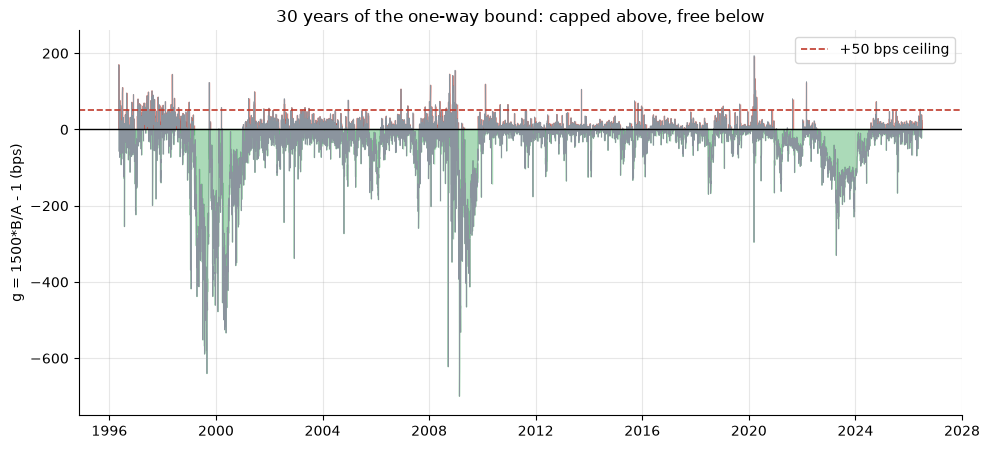

In [2]:
if HAVE_REAL:
    vb = st.violation_stats(BRK); vg = st.violation_stats(GOO)
    rows = [(thr, vb[f'above_{thr}bps_share']*100, vb[f'above_{thr}bps_days']) for thr in (0,10,50,100)]
    asym = (vb['dn50_share']*100, vb['up50_share']*100, vb['asym_ratio'],
            vg['up50_share']*100, vg['dn50_share']*100)
else:
    rows = R['viol']; asym = (R['brk_dn50'], R['brk_up50'], R['asym_brk'], R['goog_up50'], R['goog_dn50'])
print('BRK-B above parity by more than:')
for thr, sh, dd in rows: print(f'   {thr:>4d} bps : {sh:5.2f}% of days ({dd} days)')
print(f'tail asymmetry beyond +/-50bps: below {asym[0]:.2f}% vs above {asym[1]:.2f}%  ->  {asym[2]:.1f}x')
print(f'GOOG control: above {asym[3]:.2f}% vs below {asym[4]:.2f}%  (no bound: symmetric)')
if HAVE_REAL:
    fig, ax = plt.subplots(figsize=(10, 4.6))
    ax.plot(BRK.index, BRK.values*1e4, lw=.5, color=GREY)
    ax.axhline(50, color=RED, ls='--', lw=1.2, label='+50 bps ceiling')
    ax.axhline(0, color='k', lw=1)
    ax.fill_between(BRK.index, 0, (BRK*1e4).where(BRK>0).values, color=RED, alpha=.6)
    ax.fill_between(BRK.index, 0, (BRK*1e4).where(BRK<0).values, color=GREEN, alpha=.4)
    ax.set_ylabel('g = 1500*B/A - 1 (bps)'); ax.set_ylim(-750, 260)
    ax.set_title('30 years of the one-way bound: capped above, free below'); ax.legend()
    plt.tight_layout(); plt.show()

> 💡 In plain words: beyond +50 bps — where stale prints can't hide — the "violations" are **1.77%** of days (134 days in 30 years, clustered in 1996–98, 2008 and March 2020; worst **+194 bps** on 2020-03-13), against **22.95%** of days below — a **13×** asymmetry. The GOOG pair is 0.7× — i.e., symmetric. The ceiling exists exactly where the conversion right exists.

### 4b · The structural discount — HAC t, by era

The gap is heavily autocorrelated (ρ ≈ 0.86), so the mean gets a Newey-West t.

mean -35.5 bps  HAC t = -12.53 (lags=10, n=7,583)
median -8.2  std 82  p1 -385.7  p99 +62.7


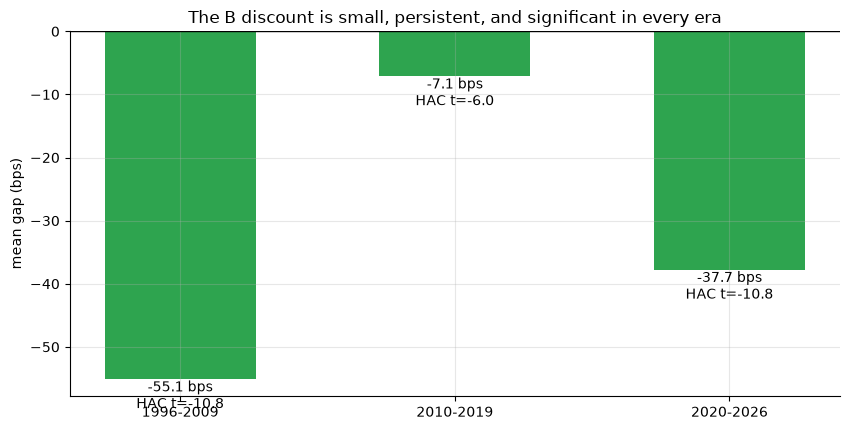

eras: [('1996-2009', np.float64(-55.1), -10.82), ('2010-2019', np.float64(-7.1), -5.99), ('2020-2026', np.float64(-37.7), -10.83)]


In [3]:
if HAVE_REAL:
    ds = st.dist_stats(BRK)
    eras = []
    for lbl, s in [('1996-2009', BRK[:'2010-01-20']), ('2010-2019', BRK['2010-01-21':'2019']), ('2020-2026', BRK['2020':])]:
        d2 = st.dist_stats(s); eras.append((lbl, d2['mean_bps'], d2['hac_t']))
    print(f"mean {ds['mean_bps']:+.1f} bps  HAC t = {ds['hac_t']:+.2f} (lags={ds['hac_lags']}, n={ds['n']:,})")
    print(f"median {ds['median_bps']:+.1f}  std {ds['std_bps']:.0f}  p1 {ds['p1_bps']:+.1f}  p99 {ds['p99_bps']:+.1f}")
else:
    eras = [(l, m, t) for l, m, t, _ in R['brk_eras']]
    print(f"mean {R['mean_bps']:+.1f} bps  HAC t = {R['hac_t']:+.2f} (frozen)")
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar([e[0] for e in eras], [e[1] for e in eras], color=GREEN, width=.55)
for i, e in enumerate(eras): ax.annotate(f'{e[1]:+.1f} bps\nHAC t={e[2]:+.1f}', (i, e[1]), ha='center', va='top')
ax.axhline(0, color='k', lw=1); ax.set_ylabel('mean gap (bps)')
ax.set_title('The B discount is small, persistent, and significant in every era')
plt.tight_layout(); plt.show()
print('eras:', [(e[0], round(e[1],1), round(e[2],2)) for e in eras])

> 💡 In plain words: the B has averaged **-35.5 bps cheap** for 30 years (**HAC t = -12.53**), from -55 bps in the wild early era to -7 bps in the placid 2010s and back to -38 bps since 2020. The distribution is the bound's fingerprint: p99 = **+63 bps** (capped) vs p1 = **-386 bps** (free).

### 4c · The unbounded control — GOOGL vs GOOG

No conversion bridge, so the voting spread should wander — and it does more than that: it changed sign.

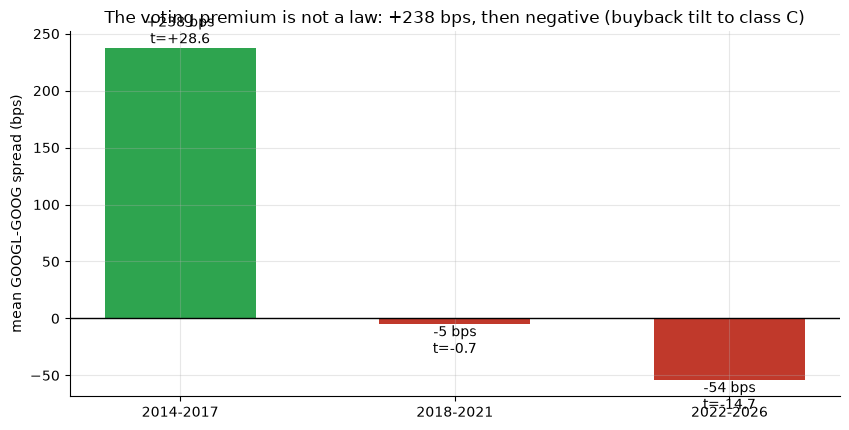

GOOG eras: [('2014-2017', np.float64(237.5), 28.59, 0), ('2018-2021', np.float64(-4.8), -0.65, 50), ('2022-2026', np.float64(-53.9), -14.74, 90)]


In [4]:
if HAVE_REAL:
    geras = []
    for lbl, s in [('2014-2017', GOO[:'2017']), ('2018-2021', GOO['2018':'2021']), ('2022-2026', GOO['2022':])]:
        d2 = st.dist_stats(s); geras.append((lbl, d2['mean_bps'], d2['hac_t'], (s<0).mean()*100))
else:
    geras = R['goog_eras']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
cols = [GREEN if e[1] > 0 else RED for e in geras]
ax.bar([e[0] for e in geras], [e[1] for e in geras], color=cols, width=.55)
for i, e in enumerate(geras):
    ax.annotate(f'{e[1]:+.0f} bps\nt={e[2]:+.1f}', (i, e[1]), ha='center',
                va='bottom' if e[1] > 0 else 'top')
ax.axhline(0, color='k', lw=1); ax.set_ylabel('mean GOOGL-GOOG spread (bps)')
ax.set_title('The voting premium is not a law: +238 bps, then negative (buyback tilt to class C)')
plt.tight_layout(); plt.show()
print('GOOG eras:', [(e[0], round(e[1],1), round(e[2],2), round(e[3])) for e in geras])

> 💡 In plain words: the "voting premium" was **+238 bps** (t = 28.6) in 2014–17, statistically zero in 2018–21, and **-54 bps** (t = -14.7) since 2022, with GOOGL *below* GOOG on 90% of days — Alphabet's buybacks concentrate in class C. Spread std **149 bps** vs the bounded pair's 82 bps; half-life **85 trading days** vs **4.5** (AR(1) ρ 0.9919 vs 0.8566). No mechanism, no anchor.

### 4d · Tradability — the fill convention is the whole result

Both rules, both conventions. `fill='same'` books the trade at the very close prints that generated the signal (only achievable by front-running your own data); `fill='next'` waits for the first close you could genuinely trade — the desk's one honest lag.

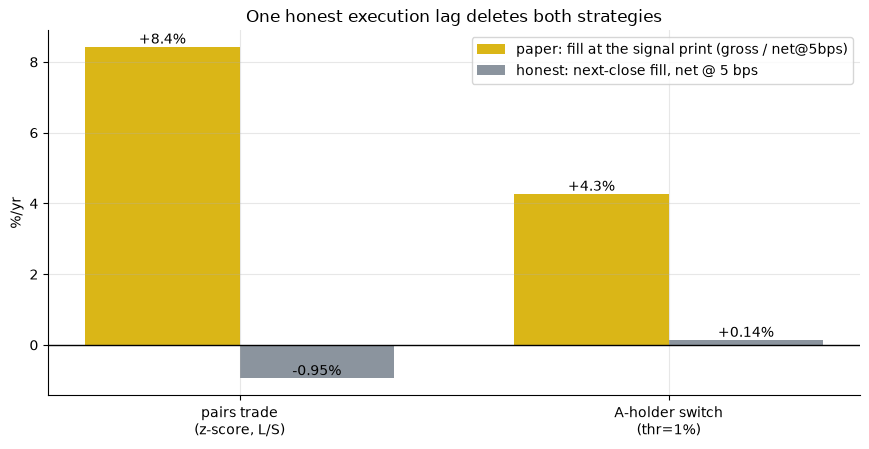

pairs: paper gross +8.42%/yr (t=+9.38) -> honest net: 2bps +0.21%/yr (t=+0.38), 5bps -0.95%/yr (t=-1.69), 10bps -2.87%/yr (t=-4.75)
switch thr=1%: paper +4.27%/yr (t=+6.02) -> honest +0.14%/yr (t=+0.28)


In [5]:
if HAVE_REAL:
    pd_ = st.pairs_trade(PX, 'BRK-A', 'BRK-B', data.BRK_PARITY, fill='same', cost_bps=0.0, borrow_bps_yr=0.0)
    pairs_rows = [(cb, st.pairs_trade(PX, 'BRK-A', 'BRK-B', data.BRK_PARITY, fill='next', cost_bps=cb))
                  for cb in (2.0, 5.0, 10.0)]
    pdg = (pd_['gross_ann_pct'], pd_['gross_t'])
    prow = [(cb, r['net_ann_pct'], r['net_t']) for cb, r in pairs_rows]
    sd = st.switch_overlay(PX, 'BRK-A', 'BRK-B', data.BRK_PARITY, thr=0.01, cost_bps=5.0, fill='same')
    sh = st.switch_overlay(PX, 'BRK-A', 'BRK-B', data.BRK_PARITY, thr=0.01, cost_bps=5.0, fill='next')
    sdg = (sd['net_ann_pct'], sd['hac_t']); shn = (sh['net_ann_pct'], sh['hac_t'])
else:
    pdg = R['pairs_diag'][:2]; prow = R['pairs']
    sdg = R['sw_diag'][:2]; shn = (R['switch'][1][1], R['switch'][1][2])
labels = ['pairs trade\n(z-score, L/S)', 'A-holder switch\n(thr=1%)']
paper = [pdg[0], sdg[0]]; honest = [prow[1][1], shn[0]]
x = np.arange(2); w = 0.36
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.bar(x - w/2, paper, w, color=AMBER, label='paper: fill at the signal print (gross / net@5bps)')
ax.bar(x + w/2, honest, w, color=GREY, label='honest: next-close fill, net @ 5 bps')
for i, v in enumerate(paper): ax.annotate(f'{v:+.1f}%', (i - w/2, v), ha='center', va='bottom')
for i, v in enumerate(honest): ax.annotate(f'{v:+.2f}%', (i + w/2, v), ha='center', va='bottom')
ax.axhline(0, color='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('%/yr'); ax.set_title('One honest execution lag deletes both strategies')
ax.legend(); plt.tight_layout(); plt.show()
print(f'pairs: paper gross {pdg[0]:+.2f}%/yr (t={pdg[1]:+.2f}) -> honest net: ' +
      ', '.join(f'{cb:.0f}bps {v:+.2f}%/yr (t={t:+.2f})' for cb, v, t in prow))
print(f'switch thr=1%: paper {sdg[0]:+.2f}%/yr (t={sdg[1]:+.2f}) -> honest {shn[0]:+.2f}%/yr (t={shn[1]:+.2f})')

> 💡 In plain words: the pairs trade reads **+8.4%/yr at t = 9.4** if you pretend to trade the signal's own prints, and **+0.21%/yr at t = +0.38** (2 bps, borrow paid) the moment you can't — negative at 5 bps and beyond. The signal *is* the microstructure noise of BRK-A's close. Add the access walls (a ~$750k minimum lot on the A leg, one-way broker-mediated conversion, a 35-bps average prize) and Tradability is a textbook **MIRAGE**.

### 4e · Third axis — was the discount *ever* a signal for A-holders?

Full threshold × era grid for the honest-fill switch overlay (net @ 5 bps, 2 legs per switch). If deep discounts were ever genuinely harvestable — say pre-2010, when −2% days were common — it must show here.

  thr |  full net      t |  pre-2010      t |     2010+      t
 0.5% |    -0.56%  -1.03 |    -1.06%  -0.93 |    -0.15%  -0.39
 1.0% |    +0.14%  +0.28 |    +0.13%  +0.12 |    +0.14%  +0.43
 2.0% |    +0.30%  +0.73 |    +0.67%  +0.74 |    -0.01%  -0.04
 3.0% |    +0.42%  +1.18 |    +0.76%  +0.95 |    +0.14%  +1.00


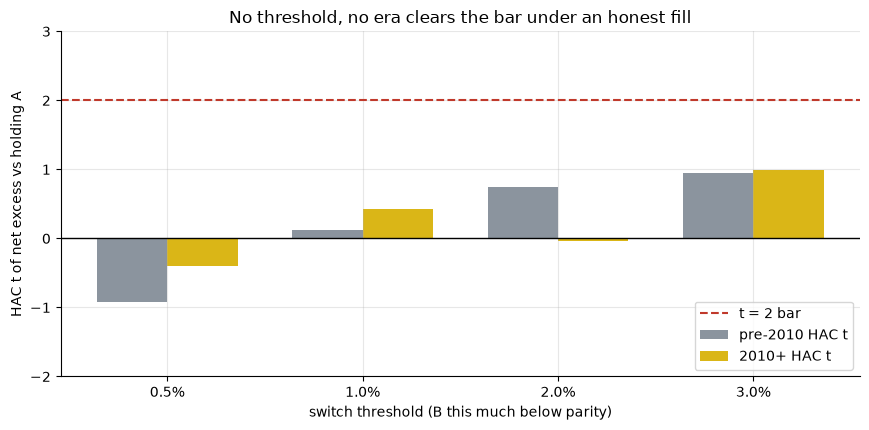

In [6]:
if HAVE_REAL:
    grid = []
    for thr in (0.005, 0.01, 0.02, 0.03):
        sw = st.switch_overlay(PX, 'BRK-A', 'BRK-B', data.BRK_PARITY, thr=thr, cost_bps=5.0, fill='next')
        e = sw['excess']; pre, post = e[:'2009'], e['2010':]
        tp, _, _ = st.hac_t(pre.values); tq, _, _ = st.hac_t(post.values)
        grid.append((thr*100, sw['net_ann_pct'], sw['hac_t'],
                     pre.mean()*252*100, tp, post.mean()*252*100, tq))
else:
    grid = R['switch']
print(f"{'thr':>5} | {'full net':>9} {'t':>6} | {'pre-2010':>9} {'t':>6} | {'2010+':>9} {'t':>6}")
for g in grid:
    print(f'{g[0]:4.1f}% | {g[1]:+8.2f}% {g[2]:+6.2f} | {g[3]:+8.2f}% {g[4]:+6.2f} | {g[5]:+8.2f}% {g[6]:+6.2f}')
fig, ax = plt.subplots(figsize=(8.8, 4.4))
x = np.arange(len(grid)); w = 0.36
ax.bar(x - w/2, [g[4] for g in grid], w, color=GREY, label='pre-2010 HAC t')
ax.bar(x + w/2, [g[6] for g in grid], w, color=AMBER, label='2010+ HAC t')
ax.axhline(2, ls='--', c=RED, label='t = 2 bar'); ax.axhline(0, color='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{g[0]:.1f}%' for g in grid])
ax.set_xlabel('switch threshold (B this much below parity)'); ax.set_ylabel('HAC t of net excess vs holding A')
ax.set_ylim(-2, 3); ax.set_title('No threshold, no era clears the bar under an honest fill')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: **never.** Across thresholds 0.5–3% and both eras the honest net excess sits between -0.56%/yr and +0.42%/yr with **t between -1.03 and +1.18** — even the wild pre-2010 discounts (−7% at the 2009 trough) snapped back by the first close you could trade (half-life 4.5 days). The B-discount has **never** been a tradable signal for A-holders: **BUSTED**.

### 4f · Faithful-engine control — we know the truth here

A deterministic two-class world (seed 621): shared GBM fundamental, AR(1) relative-value gap, class-specific print noise. World 1 plants a −40 bps mean discount **and** a hard one-way bound; world 2 is a symmetric unbounded null with zero mean gap. The detector (mean-gap HAC t + ±50 bps tail asymmetry) must flag the first and stay quiet on the second.

PLANTED bound + -40bps  : mean  -54.9 bps  HAC t =  -33.86  above +50bps  0.00%  below -50bps 52.64%


NULL no bound, 0 gap    : mean   -3.1 bps  HAC t =   -1.50  above +50bps 14.40%  below -50bps 16.98%


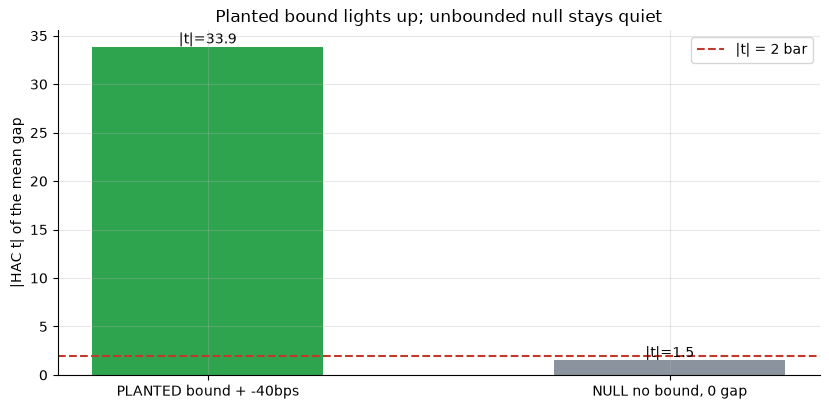

In [7]:
rows = []
for lbl, kw in [('PLANTED bound + -40bps', dict(mean_discount=-0.004, bound=True)),
                ('NULL no bound, 0 gap', dict(mean_discount=0.0, bound=False))]:
    spx = data.synthetic_pair(seed=621, **kw)
    det = st.bound_detector(spx, data.BRK_PARITY)
    rows.append((lbl, det['mean_bps'], det['hac_t'], det['up50_share']*100, det['dn50_share']*100))
    print(f"{lbl:24s}: mean {det['mean_bps']:+6.1f} bps  HAC t = {det['hac_t']:+7.2f}  "
          f"above +50bps {det['up50_share']*100:5.2f}%  below -50bps {det['dn50_share']*100:5.2f}%")
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar([r[0] for r in rows], [abs(r[2]) for r in rows], color=[GREEN, GREY], width=.5)
ax.axhline(2, ls='--', c=RED, label='|t| = 2 bar')
for i, r in enumerate(rows): ax.annotate(f'|t|={abs(r[2]):.1f}', (i, abs(r[2])), ha='center', va='bottom')
ax.set_ylabel('|HAC t| of the mean gap'); ax.set_title('Planted bound lights up; unbounded null stays quiet')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: the planted world reads mean -54.9 bps at **HAC t = -33.86** with a zero upward tail; the null reads -3.1 bps at **t = -1.50** with near-symmetric tails (14.4% vs 17.0%). The machinery detects exactly what is planted and nothing else. *(A machinery proof — never cited in support of the stamps.)*

## 5 · The verdict

- **Signal `REAL`** — the one-way bound is on the tape: >+50 bps on **1.77%** of days (>+100 bps: 0.24%; worst +194 bps, 2020-03-13) vs 22.95% below (**13×** asymmetry), mean discount **-35.5 bps** at **HAC t = -12.53** (all eras significant), half-life 4.5d vs 85d for the unbounded GOOG control whose spread even flipped sign. Clears t ≥ 2 on the real tape many times over.
- **Tradability `MIRAGE`** — honest one-lag pairs trade: +0.21%/yr (t = +0.38) at 2 bps, -0.95%/yr at 5 bps, -2.87%/yr at 10 bps; the +8.4%/yr paper number is a same-print fill artefact. $750k minimum lot, one-way conversion, 35-bps prize.
- **Tradable for A-holders? `BUSTED`** — switch overlay t ≤ 1.18 at every threshold in every era under an honest fill (vs t = 6.02 at the fill-at-print illusion).

## 6 · Going further

- **The bound is a free option with one owner class.** Only A-holders can mint B; that privilege is why enforcement is instant on top and slow underneath (closing the discount needs slow-moving long-A/short-B capital — Shleifer-Vishny limits in miniature).
- **The mirage generalises.** Any relative-value study with one stale leg (ADR pairs, A/H twins, holdco stubs) manufactures t > 5 alpha under a same-close fill. Report the fill convention or report nothing.
- **Siblings on the desk.** [05-twin-spread](../../05-twin-spread/README.md) trades *statistical* pairs with no contractual anchor; [367-closed-end-fund-discount](../../367-closed-end-fund-discount/README.md) has a NAV and no conversion; [618-gbtc-premium-cycle](../../618-gbtc-premium-cycle/README.md) shows what happens when a one-way bridge breaks; [620-a-h-premium](../../620-a-h-premium/README.md) segments by market access. This study is the limiting case: a bound that is *contractual*, tested against its own bridgeless twin.

*The reproducible core is offline and deterministic; every number here is printed by [`examples/verify.py`](../examples/verify.py) and frozen in [`docs/results.md`](../docs/results.md).*